In [ ]:
""" twisted bilayer MoTe2 的无相互作用哈密顿量 H0"""
"""Wu 2019 PRL"""
import matplotlib.pyplot as plt
import numpy as np

"""参数"""
theta = np.radians(1.2)  # 转角 (unit in rad)
a0 = 3.472 # MoTe2晶格常数 (unit in Angstrom)
aM = a0 / (2 * np.sin(theta / 2)) # moire晶格常数 (unit in Angstrom)
bM = 4*np.pi/(np.sqrt(3)*aM) # 倒格矢量长度 (unit in Angstrom^-1)
angles = np.array([0, 1*np.pi/3, 2*np.pi/3, 3*np.pi/3, 4*np.pi/3, 5*np.pi/3]) # 所有倒格矢量的角度
b = bM * np.stack([np.cos(angles), np.sin(angles)], axis=1) # 所有倒格矢量
V = 8e-3 # moire周期势 （unit in eV） 
psi = np.radians(-89.6) # psi和V控制了对角项上的moire势部分 (unit in rad)
Nbloch = 5
h2m = 6.145    #  这个量用作对角线元素中的动能项 (unit in eV·Angstrom^+2) 
w = -8.5e-3 # 隧穿幅度 （unit in eV）
Kt = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), -np.sin(np.pi/6)], axis=0) #K_t 对应 K_+ 
Kb = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), +np.sin(np.pi/6)], axis=0) #K_b 对应 K_-  

"""
#构造哈密顿量H0,对角项除了动量项还有上下层分别的Moire势，
#Delta = 2V sum cos(b_i cdot r + psi) = V * sum exp(1i*psi)*exp(1i*b_i * r) + exp(-1i*psi)*exp(-1i*b_i * r)
#这个含r的项的傅里叶变换给出动量空间的矩阵元<p|V|q> = V sum_i (exp(1i*psi)delta(p-q-b_i) + exp(-1i*psi)delta(p-q+b_i))
#现在要把分立的bloch模式写出来，不同的bloch模式之间应用<p|V|q>的非对角元描述，哈密顿矩阵扩张成为2(2N+1)维度，其中Nbloch是bloch模式的截断
"""
Gs = np.array([m*b[0] + n*b[2]
                   for m in range(-Nbloch, Nbloch+1)
                       for n in range(-Nbloch, Nbloch+1)]
                 )
lenG = len(Gs)

"""构造moire周期势 Delta_t/b """
Delta_t = np.zeros((lenG, lenG), dtype=complex)
Delta_b = np.zeros((lenG, lenG), dtype=complex)
for ip,Gp in enumerate(Gs):
    for iq, Gq in enumerate(Gs):
        for j, bj in enumerate([b[0],b[2],b[4]]):
            # Gp = Gq + bj -> <p|exp(ib*r) |q>
            Delta_t[ip,iq] += V  * (np.linalg.norm(bj + Gq - Gp) < 1e-8) * np.exp(+1j * psi)
            Delta_b[ip,iq] += V  * (np.linalg.norm(bj + Gq - Gp) < 1e-8) * np.exp(-1j * psi)
            # Gp = Gq - bj -> <p|exp(-ib*r)|q>
            Delta_t[ip,iq] += V  * (np.linalg.norm(-bj + Gq - Gp) < 1e-8) * np.exp(-1j * psi)
            Delta_b[ip,iq] += V  * (np.linalg.norm(-bj + Gq - Gp) < 1e-8) * np.exp(+1j * psi)
            
""" 构造隧穿矩阵T"""
T = np.zeros((lenG, lenG))
for ip, Gp in enumerate(Gs):
    for iq, Gq in enumerate(Gs):
        bzero = np.stack([0,0],axis=0)
        for j, bj in enumerate([bzero, b[1], b[2]]):
            # Gp = Gq + bj or Gp = Gq,  p,q属于不同层的bloch基底，这里算的是右上角bt
            T[ip,iq] += w * (np.linalg.norm(-bj + Gq - Gp) < 1e-8)

""" 这里首先拼出不依赖动量k的部分，包含moire势以及隧穿项"""
H0 = np.block([[Delta_t, T],[T.conj().T, Delta_b]])

"""计算H0中的动能项"""
def H0_diag(k, Gs, Kt, Kb):
    # 我现在的基底是bloch平面波psi_i，我的每个基底在p算符下的动量为k->k+G_i
    diagts = []
    diagbs = []
    for i, Gi in enumerate(Gs):
        diagt = -h2m * (np.linalg.norm(k  + Gi - Kt)) **2
        diagb = -h2m * (np.linalg.norm(k  + Gi - Kb)) **2
        diagts.append(diagt)
        diagbs.append(diagb)

    H0diag = np.diag(diagts + diagbs)
    return H0diag

"""高对称点路径上每一个点进行对角化"""
G = np.array([0.0, 0.0])
M = bM * np.array([-1/2, 0.0])
Kplus = bM * np.array([-1/2, +1/(2*np.sqrt(3))])
Kminus = bM * np.array([-1/2, -1/(2*np.sqrt(3))])
Kp = bM * np.array([+1/2, -1/(2*np.sqrt(3))])

def kpoints(start, end, n):
    return [start + i/n * (end - start) for i in range(n)]

kpath = (kpoints(Kp,G,50)+ kpoints(G, Kplus, 50) + kpoints(Kplus, M, 25) + kpoints(M, Kminus, 25) + kpoints(Kminus, Kp, 100))

eigvals = []
for k in kpath:
    H0diag = H0_diag(k, Gs, Kt, Kb)
    H0tot = H0 + H0diag
    evals, evecs = np.linalg.eigh(H0tot)
    eigvals.append(evals)

    
eigvals = np.array(eigvals)   
Nk = eigvals.shape[0]         
dim = eigvals.shape[1]   
k_index = np.arange(Nk)
E_min, E_max = -25, 25
plt.figure(figsize=(6, 5))

for n in range(dim):
    E_n = eigvals[:, n]       # 第 n 条带
    if E_n.min() < E_max and E_n.max() > E_min:
        plt.plot(k_index, E_n *1000, lw=1.0, color = 'k')

kk2 = [0, 50, 100, 125, 150,250-1]
kk1 = ["K'", r"$\Gamma$", "K+", "M", "K-", "K'"]
plt.xticks(kk2, kk1, fontsize=12)
plt.ylabel('E (meV)', fontsize=13)
plt.ylim(E_min, E_max)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
"""计算第一价带的陈数"""
"""现在不用六角形miniBZ，换成一个平行四边形区域计算微元上的曲率"""
"""F^hatsugai_kx_ky = arg(<u_k|u_k+dkx> * <u_k+dkx|u_k+dkx+dky> * <u_dkx+dky|u_k+dky> * <u_dky|u_k>)"""

def calc_chern (bx, by, step, band_id):
    dbx = bx/step
    dby = by/step
    
    vecs = np.zeros((step+1, step+1, dim), dtype = complex)
    for i in range(0,step+1):
        for j in range(0,step+1):
            k = i * dbx + j * dby
            H0tot = H0 + H0_diag(k, Gs, Kt, Kb)
            _, v = np.linalg.eigh(H0tot)
            vecs[i,j,:] = v[:,-band_id]
    
    F = np.zeros((step,step))
    for i in range(0,step):
        for j in range(0,step):
            vs = [vecs[i,j,:], vecs[i+1,j,:],vecs[i+1,j+1,:],vecs[i,j+1,:]]   
            ua = np.vdot(vs[0],vs[1]) 
            ub = np.vdot(vs[1],vs[2])
            uc = np.vdot(vs[2],vs[3])
            ud = np.vdot(vs[3],vs[0])
            Zi = ua*ub*uc*ud
            F[i,j] = np.angle(Zi)
    return F

step = 5
band_id = 1
F = calc_chern(b[0], b[1], step, band_id)
ch = np.sum(F[:step, :step]) / (2 * np.pi)
print(f"chern_number {ch:.5f} band {band_id}")

chern_number 1.00000 band 1


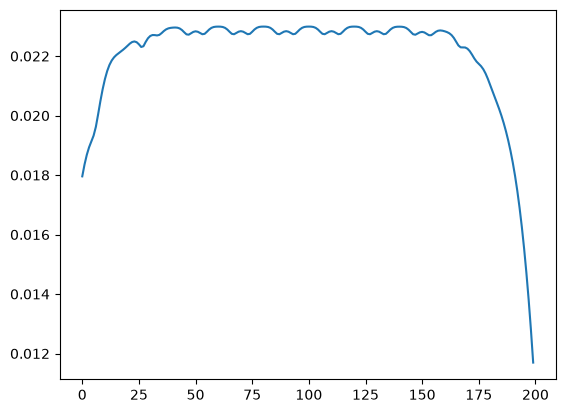

In [5]:
"""验证哈密顿量沿着某个方向在某个范围是否有周期性"""
path = kpoints(-15*Kp,15*Kp,200)
etot = []
for  i,k in enumerate(path):
    H0tot = H0 + H0_diag(k, Gs, Kt, Kb)
    e,v = np.linalg.eigh(H0tot)
    etot.append(e[-1])
    
plt.plot(etot)

路径点数 Nk = 175
矩阵维度 dim = 50


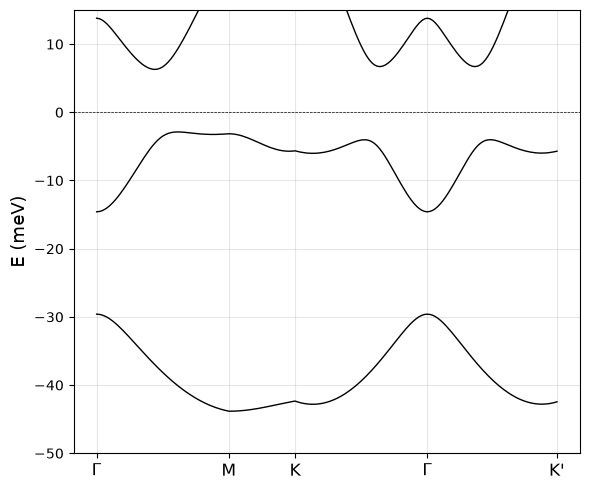

In [4]:
""" twisted bilayer MoTe2 的无相互作用哈密顿量 H0"""
"""Song 2024 PRB"""
import matplotlib.pyplot as plt
import numpy as np

"""参数"""
theta = np.radians(3.89)  # 转角 (unit in rad)
a0 = 3.52 # MoTe2晶格常数 (unit in Angstrom)
aM = a0 / (2 * np.sin(theta / 2)) # moire晶格常数 (unit in Angstrom)
bM = 4*np.pi/(np.sqrt(3)*aM) # 倒格矢量长度 (unit in Angstrom^-1)
angles = np.array([0, 1*np.pi/3, 2*np.pi/3, 3*np.pi/3, 4*np.pi/3, 5*np.pi/3]) # 所有倒格矢量的角度
b = bM * np.stack([np.cos(angles), np.sin(angles)], axis=1) # 所有倒格矢量
V = 20.8e-3 # moire周期势 （unit in eV） 
psi = np.radians(107.7) # psi和V控制了对角项上的moire势部分 (unit in rad)
Nbloch = 2
h2m = 6.145    #  这个量用作对角线元素中的动能项 hbar^2/2m* (unit in eV·Angstrom^+2)
w = -23.8e-3 # 隧穿幅度 （unit in eV）
Kt = bM/np.sqrt(3) * np.stack([+np.cos(np.pi/6), +np.sin(np.pi/6)], axis=0) #K_t 对应 K_+ 
Kb = bM/np.sqrt(3) * np.stack([+np.cos(np.pi/6), -np.sin(np.pi/6)], axis=0) #K_b 对应 K_-  

"""
#构造哈密顿量H0,对角项除了动量项还有上下层分别的Moire势，
#Delta = 2V sum cos(b_i cdot r + psi) = V * sum exp(1i*psi)*exp(1i*b_i * r) + exp(-1i*psi)*exp(-1i*b_i * r)
#这个含r的项的傅里叶变换给出动量空间的矩阵元<p|V|q> = V sum_i (exp(1i*psi)delta(p-q-b_i) + exp(-1i*psi)delta(p-q+b_i))
#现在要把分立的bloch模式写出来，不同的bloch模式之间应用<p|V|q>的非对角元描述，哈密顿矩阵扩张成为2(2N+1)维度，其中Nbloch是bloch模式的截断
"""
Gs = np.array([m*b[0] + n*b[2]
                   for m in range(-Nbloch, Nbloch+1)
                       for n in range(-Nbloch, Nbloch+1)]
                 )
lenG = len(Gs)

"""构造moire周期势 Delta_t/b """
Delta_t = np.zeros((lenG, lenG), dtype=complex)
Delta_b = np.zeros((lenG, lenG), dtype=complex)
for ip,Gp in enumerate(Gs):
    for iq, Gq in enumerate(Gs):
        for j, bj in enumerate([b[0],b[2],b[4]]):
            # Gp = Gq + bj -> <p|exp(ib*r) |q>
            Delta_t[ip,iq] += V * np.exp(+1j * psi) * (np.linalg.norm(bj + Gq - Gp) < 1e-8)
            Delta_b[ip,iq] += V * np.exp(-1j * psi) * (np.linalg.norm(bj + Gq - Gp) < 1e-8)
            # Gp = Gq - bj -> <p|exp(-ib*r)|q>
            Delta_t[ip,iq] += V * np.exp(-1j * psi) * (np.linalg.norm(-bj + Gq - Gp) < 1e-8)
            Delta_b[ip,iq] += V * np.exp(+1j * psi) * (np.linalg.norm(-bj + Gq - Gp) < 1e-8)
            
""" 构造隧穿矩阵T"""
T = np.zeros((lenG, lenG))
for ip, Gp in enumerate(Gs):
    for iq, Gq in enumerate(Gs):
        bzero = np.stack([0,0],axis=0)
        for j, bj in enumerate([bzero, b[1], b[2]]):
            # Gp = Gq + bj or Gp = Gq,  p,q属于不同层的bloch基底，这里算的是右上角bt
            T[ip,iq] += w * (np.linalg.norm(+bj + Gq - Gp) < 1e-8)

""" 这里首先拼出不依赖动量k的部分，包含moire势以及隧穿项"""
H0 = np.block([[Delta_t, T],[T.T, Delta_b]])

"""计算H0中的动能项"""
def H0_diag(k, Gs, Kt, Kb):
    # 我现在的基底是bloch平面波psi_i，我的每个基底在p算符下的动量为k->k+G_i
    diagts = []
    diagbs = []
    for i, Gi in enumerate(Gs):
        diagt = +h2m * (np.linalg.norm(k  + Gi - Kt)) **2
        diagb = +h2m * (np.linalg.norm(k  + Gi - Kb)) **2
        diagts.append(diagt)
        diagbs.append(diagb)

    H0diag = np.diag(diagts + diagbs)
    return H0diag

"""高对称点路径上每一个点进行对角化"""
G = bM * np.array([0.0, 0.0])
M = bM * np.array([np.sqrt(3)/4, 1/4])
K = bM * np.array([1/np.sqrt(3), 0])
Kp = bM * np.array([1/(2*np.sqrt(3)),1/2])

def kpoints(start, end, n):
    return [start + i/n * (end - start) for i in range(n)]

kpath = (kpoints(G,M,50)+ kpoints(M, K, 25) + kpoints(K, G, 50) + kpoints(G, Kp, 50) )

eigvals = []
for k in kpath:
    H0diag = H0_diag(k, Gs, Kt, Kb)
    H0tot = H0 + H0diag
    evals = np.linalg.eigvalsh(H0tot)
    eigvals.append(evals)
eigvals = np.array(eigvals)   

Nk = eigvals.shape[0]         
dim = eigvals.shape[1]        
print(f"路径点数 Nk = {Nk}")
print(f"矩阵维度 dim = {dim}")
k_index = np.arange(Nk)
E_min, E_max = -50, 15
plt.figure(figsize=(6, 5))

for n in range(dim):
    E_n = eigvals[:, n]       # 第 n 条带
    if E_n.min() < E_max and E_n.max() > E_min:
        plt.plot(k_index, E_n *1000, lw=1.0, color = 'k')

kk2 = [0, 50, 75, 125, 175-1]
kk1 = [ r"$\Gamma$", "M", "K", r"$\Gamma$" , "K'"]
plt.xticks(kk2, kk1, fontsize=12)
plt.ylabel('E (meV)', fontsize=13)
plt.ylim(E_min, E_max)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

